## Breast Cancer Detection Using Machine Learning Classifier

In [ ]:
"""
Goal: We have extracted features of breast cancer patient's cell and normal person's cell.
        As ML engineer/Data Scientist, need to classify malignant and benign tumor.
        To complete this prediction, we are using Supervised Machine Learning Classifier Algorithm.
"""

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load breast-cancer dataset

from sklearn.datasets import load_breast_cancer
cancer_data = load_breast_cancer()

In [ ]:
cancer_data.keys()

In [ ]:
cancer_data['target_names']

In [3]:
# create dataframe

cancer_df = pd.DataFrame(np.c_[cancer_data['data'],cancer_data['target']],
                        columns= np.append(cancer_data['feature_names'],['target'])
                        )

In [4]:
cancer_df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [ ]:
cancer_df.head()

In [ ]:
cancer_df.to_csv('breast_cancer_data')

In [ ]:
cancer_df.isnull().sum()

## Data Visualization

In [ ]:
sns.pairplot(cancer_df, hue = 'target', vars=['mean radius','mean texture','mean perimeter','mean area','mean smoothness','mean compactness' ])

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(cancer_df['target'])

In [ ]:
plt.figure(figsize=(16,10))
sns.heatmap(cancer_df)

## Feature Scaling

In [5]:
X = cancer_df.drop('target',axis=1)
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
y= cancer_df['target']
y.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: target, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=5)

In [8]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)


## Machine Learning Model Building 

In [9]:
## confusion_matrix() → Shows where the model is making mistakes.
## classification_report() → Shows precision, recall, and F1-score values calculated from those mistakes
## accuracy_score() calculates the percentage of correct predictions made by the model. It is one of the simplest classification evaluation metrics.
    # Formula
    # Accuracy = {TP + TN}/{TP + TN + FP + FN}

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
"""
We have clean data to build the Ml model. But which Machine learning algorithm is best for the data we have to find. 
The output is a categorical format so we will use supervised classification machine learning algorithms.
To build the best model, we have to train and test the dataset with multiple Machine Learning algorithms then we can find the best ML model. 
So let’s try.
"""

### Support Vector

In [ ]:
# support vector classifier

from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test, y_pred)

In [ ]:
# Train with standard scaler data.

svc_2 = SVC()
svc_2.fit(X_train_sc,y_train)
y_pred_2 = svc_2.predict(X_test_sc)
accuracy_score(y_test, y_pred_2)

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=51, penalty='l2')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)


In [ ]:
lr2 = LogisticRegression(random_state=51, penalty='l2')
lr2.fit(X_train_sc, y_train)
y_pred2 = lr2.predict(X_test_sc)
accuracy_score(y_test, y_pred2)



### K-Nearest Neighbor 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors= 5, metric= 'minkowski', p= 2)
knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)
accuracy_score(y_test, y_pred_knn)

In [ ]:
knn_2 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_2.fit(X_train_sc, y_train)
y_pred_knn_sc= knn_2.predict(X_test_sc)
accuracy_score(y_test, y_pred_knn_sc)

### Naive-Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
accuracy_score(y_test, y_pred_nb)

In [ ]:
nb_sc= GaussianNB()
nb_sc.fit(X_train_sc, y_train)
y_pred_nb_sc = nb_sc.predict(X_test_sc)
accuracy_score(y_test, y_pred_nb_sc)

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc= DecisionTreeClassifier(criterion='entropy' , random_state=51)
dtc.fit(X_train, y_train)
y_pred_dtc= dtc.predict(X_test)
accuracy_score(y_test, y_pred_dtc)

In [ ]:
dtc_sc = DecisionTreeClassifier(criterion='entropy', random_state=51)
dtc_sc.fit(X_train_sc, y_train)
y_pred_dtc_sc = dtc_sc.predict(X_test_sc)
accuracy_score(y_test,y_pred_dtc_sc)

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rdc = RandomForestClassifier(n_estimators=20, criterion='entropy', random_state=51)
rdc.fit(X_train, y_train)
y_pred_rdc = rdc.predict(X_test)
accuracy_score(y_test, y_pred_rdc)

In [ ]:
rdc_sc= RandomForestClassifier(n_estimators=20, criterion='entropy', random_state=51)
rdc_sc.fit(X_train_sc, y_train)
y_pred_rdc_sc= rdc.predict(X_test_sc)
accuracy_score(y_test, y_pred_rdc_sc)


### AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
adb= AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=100,learning_rate=1.0,random_state=42)
adb.fit(X_train,y_train)
y_pred_adb= adb.predict(X_test)
accuracy_score(y_test,y_pred_adb)

In [ ]:
adb_sc= AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=100,learning_rate=1.0,random_state=42)
adb_sc.fit(X_train_sc,y_train)
y_pred_adb_sc = adb_sc.predict(X_test_sc)
accuracy_score(y_test, y_pred_adb_sc)

### XGBoost Classifier

In [10]:
# pip install xgboost 

from xgboost import XGBClassifier
xgbc = XGBClassifier()
xgbc.fit(X_train, y_train)
y_pred_xgb = xgbc.predict(X_test)
accuracy_score(y_test, y_pred_xgb)

0.9736842105263158

In [11]:
xgbc_sc = XGBClassifier()
xgbc_sc.fit(X_train_sc, y_train)
y_pred_xgbc_sc = xgbc_sc.predict(X_test_sc)
accuracy_score(y_test, y_pred_xgbc_sc)

0.9736842105263158

### XGBoost Parameter Tuning Randomized Search

In [12]:
# XGBoost classifier most required parameters

# These add randomness and improve generalization. XGBoost specifically recommends these parameters to control overfitting.

params={
 "learning_rate"    : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30 ] ,
 "max_depth"        : [ 3, 4, 5, 6, 8, 10, 12, 15],
 "min_child_weight" : [ 1, 3, 5, 7 ],
 "gamma"            : [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
 "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ] 
}

from sklearn.model_selection import RandomizedSearchCV
random_s = RandomizedSearchCV(xgbc, param_distributions=params, n_jobs=-1, verbose=3, scoring='roc_auc')
random_s.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.3, 0.4, ...], 'gamma': [0.0, 0.1, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify

In [13]:
random_s.best_params_

{'min_child_weight': 1,
 'max_depth': 4,
 'learning_rate': 0.1,
 'gamma': 0.4,
 'colsample_bytree': 0.3}

In [15]:
# Training XGBoost Classifier with best parameters

xgb_classifier_pt = XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
       colsample_bynode=1, colsample_bytree=0.4, gamma=0.2,
       learning_rate=0.1, max_delta_step=0, max_depth=15,
       min_child_weight=1, n_estimators=100, n_jobs=1,
       nthread=None, objective='binary:logistic', random_state=0,
       reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
       silent=None, subsample=1, verbosity=1)
 
xgb_classifier_pt.fit(X_train, y_train)
y_pred_xgb_pt = xgb_classifier_pt.predict(X_test)

accuracy_score(y_test, y_pred_xgb_pt)

0.9736842105263158

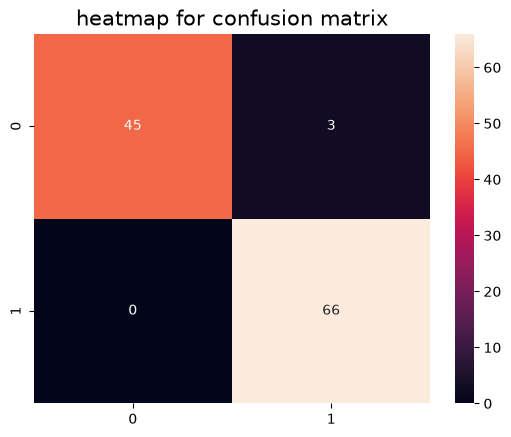

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb_pt)
plt.title('heatmap for confusion matrix', fontsize=15)
sns.heatmap(cm, annot=True)
plt.show()

In [ ]:

""" The model is giving 0% type II error and it is best."""


## Classification report of Model

In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb_pt))

              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97        48
         1.0       0.96      1.00      0.98        66

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Cross-Validation of the ML model

In [ ]:
# To find the ML model is overfitted, under fitted or generalize doing cross-validation.

In [20]:
from sklearn.model_selection import cross_val_score
cross_validation = cross_val_score(estimator= xgb_classifier_pt, X= X_train_sc, y=y_train, cv= 10)
print("Cross validation of XGBoost model = ",cross_validation)
print("Cross validation of XGBoost model (in mean) = ",cross_validation.mean())

Cross validation of XGBoost model =  [1.         0.97826087 0.97826087 1.         0.93478261 0.93333333
 1.         1.         0.95555556 0.88888889]
Cross validation of XGBoost model (in mean) =  0.9669082125603865


In [ ]:
# The mean accuracy value of cross-validation is 96.69% and XGBoost model accuracy is 97.36%. 
# It showing XGBoost is slightly overfitted but when training data will more it will generalized model.

## Save the machine Learning Model

In [ ]:
# After completion of the Machine Learning project or building the ML model need to deploy in an application. 
# To deploy the ML model need to save it first. To save the Machine Learning project we can use the pickle or joblib package.

In [22]:
import pickle
pickle.dump(xgb_classifier_pt, open('breast_cancer_detector.pickle', 'wb'))

# load model
breast_cancer_model = pickle.load(open('breast_cancer_detector.pickle', 'rb'))

# predict the output
y_pred = breast_cancer_model.predict(X_test)

print('confusion matrix: ','\n', confusion_matrix(y_test, y_pred))
print('accuracy score: ','\n', accuracy_score(y_test, y_pred))


confusion matrix:  
 [[45  3]
 [ 0 66]]
accuracy score:  
 0.9736842105263158


In [ ]:
""" Note: When we dump the model then model file is store in the disk where the project file is store but we can change path by passing its address."""


In [ ]:
"""

Congratulation!!!!!!!

We have completed the Machine learning Project successfully with 97.36% accuracy which is great for 
‘Breast Cancer Detection using Machine learning’ project. 
Now, we are ready to deploy our ML model in the healthcare project.\

"""